# Lesson Coverage

## Data Preparation

- [x] Duplicates handled
- [x] Missing Data checked / handled if necessary
- [x] Outliers inspected
- [x] Encoding
- [x] Scaling

## K-Nearest Neighbors

- [x] KNN Regression
- [x] KNN Classification
- [x] n_neighbors
- [x] weights
- [x] p = 1 / Manhattan
- [x] p = 2 / Euclidean

## Baselines

- [x] DummyRegressor
- [x] DummyClassifier

## Regression Metrics

- [x] Residuals
- [x] MSE
- [x] RMSE
- [x] MAE
- [x] Max Error
- [x] R?
- [x] cross_validate with multiple metrics

## Classification Metrics

- [x] Confusion Matrix
- [x] TP
- [x] TN
- [x] FP
- [x] FN
- [x] Accuracy
- [x] Precision
- [x] Recall
- [x] F1

## Threshold Evaluation

- [x] LabelEncoder
- [x] predict_proba
- [x] cross_val_predict
- [x] precision_recall_curve
- [x] Precision?Recall plot
- [x] Business Recall target
- [x] Custom Threshold
- [x] Precision / Recall comparison after threshold change

## ROC

- [x] ROC Curve
- [x] True Positive Rate
- [x] False Positive Rate
- [x] ROC-AUC

## Final Analysis

- [ ] Error Analysis
- [ ] Cohort Analysis
- [ ] Final metric interpretation

# 1. Project Goal

This project studies how different machine-learning evaluation metrics tell different stories about model performance using the **Medical Insurance Charges** dataset.

The project will explore two distinct machine-learning tasks:

### Task A ? Regression
Predict individual medical insurance `charges` based on patient attributes (age, sex, BMI, children, smoking status, and region).

### Task B ? Classification
Later in the project, we will create a classification target `price_range` with two categories:
- `cheap`
- `expensive`

We will evaluate classification models against various probability thresholds, trade-offs between precision and recall, and ROC-AUC.

> **Scope Notice for Step 1**: In this initial step, we focus exclusively on raw data auditing, quality checks, and outlier inspection. We do **not** create the `price_range` target yet, do **not** apply encodings or scalings, do **not** split into train/test, and do **not** train any models.

# 2. Load Data

We load the raw dataset from `data/insurance.csv` using `pandas` and inspect its basic dimensions and structure.

In [1]:
import pandas as pd

data = pd.read_csv("data/insurance.csv")

In [2]:
data.shape

(1338, 7)

In [3]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
data.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

The dataset loaded contains 1,338 rows and 7 columns, matching the expected schema:
- `age`: integer / numeric
- `sex`: string categorical (`female`, `male`)
- `bmi`: float continuous
- `children`: integer count
- `smoker`: string categorical (`yes`, `no`)
- `region`: string categorical (`northeast`, `southeast`, `southwest`, `northwest`)
- `charges`: float continuous (regression target)

# 3. Understand the Data

We now examine the data types, non-null counts, and summary statistics across all columns.

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [6]:
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


Next, we inspect the frequency distributions of each categorical variable using `value_counts()`.

In [7]:
data["sex"].value_counts()

sex
male      676
female    662
Name: count, dtype: int64

In [8]:
data["smoker"].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [9]:
data["region"].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

**Categorical Insights:**
- `sex`: Very evenly split between male (676) and female (662).
- `smoker`: Approximately 20.5% smokers (274) and 79.5% non-smokers (1,064). Smoking status may be strongly related to charges and will be examined empirically during modelling and error analysis.
- `region`: Evenly distributed across all 4 US regions (southeast has slightly more records at 364, while the others have 324?325).

# 4. Duplicates

We check for duplicate rows in the dataset using `duplicated()` and calculate the total count.

In [10]:
data.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1333    False
1334    False
1335    False
1336    False
1337    False
Length: 1338, dtype: bool

In [11]:
duplicate_count = data.duplicated().sum()
print(f"Total duplicate rows: {duplicate_count}")

Total duplicate rows: 1


In [12]:
if duplicate_count > 0:
    display(data[data.duplicated(keep=False)])
else:
    print("No duplicate rows found.")

,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


Duplicate observations can distort model evaluation if the same observation appears in both training and test data.

Inspection reveals 1 duplicate pair (row 195 and row 581: a 19-year-old male, non-smoker, BMI 30.59, 0 children, northwest, charge 1639.5631).

In Step 1, we do **not** remove duplicates yet, preserving the raw dataset exactly as loaded for audit purposes.

# 5. Missing Data

We check for missing or null values in each feature and across the entire dataset.

In [13]:
data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [14]:
total_missing = data.isnull().sum().sum()
print(f"Total missing values: {total_missing}")

Total missing values: 0


The dataset contains no missing values, so imputation is not required for this project.

# 6. Numerical / Categorical Features

We partition features by their data type into numerical and categorical subsets.

In [15]:
numerical_features = ["age", "bmi", "children", "charges"]
categorical_features = ["sex", "smoker", "region"]

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

Numerical features: ['age', 'bmi', 'children', 'charges']
Categorical features: ['sex', 'smoker', 'region']


In [16]:
data[numerical_features].dtypes

age           int64
bmi         float64
children      int64
charges     float64
dtype: object

In [17]:
data[categorical_features].dtypes

sex       str
smoker    str
region    str
dtype: object

**Distance-Based Algorithm Considerations:**

K-Nearest Neighbors (KNN) is a distance-based algorithm (computing Euclidean or Manhattan distances between data points). Consequently:
1. **Categorical features** (`sex`, `smoker`, `region`) cannot be used directly in distance formulas and will later require numerical representation (e.g., One-Hot Encoding).
2. **Numerical features** (`age`, `bmi`, `children`) have vastly different scales (e.g. `age` spans 18?64, `bmi` spans 15.96?53.13, while `charges` spans 1,121?63,770). Without appropriate feature scaling (e.g. `StandardScaler` or `RobustScaler`), features with larger magnitudes would arbitrarily dominate distance calculations.

# 7. Potential Outliers

We inspect the distribution, central tendencies, dispersion, and skewness of all numerical features.

In [18]:
summary_stats = pd.DataFrame({
    "min": data[numerical_features].min(),
    "max": data[numerical_features].max(),
    "mean": data[numerical_features].mean(),
    "median": data[numerical_features].median(),
    "std": data[numerical_features].std(),
    "skewness": data[numerical_features].skew()
})
summary_stats

,min,max,mean,median,std,skewness
age,18.0000,64.00000,39.207025,39.000,14.049960,0.055673
bmi,15.9600,53.13000,30.663397,30.400,6.098187,0.284047
children,0.0000,5.00000,1.094918,1.000,1.205493,0.938380
charges,1121.8739,63770.42801,13270.422265,9382.033,12110.011237,1.515880


We visualize the distributions and potential outliers for `bmi` and `charges` using simple `matplotlib` boxplots.

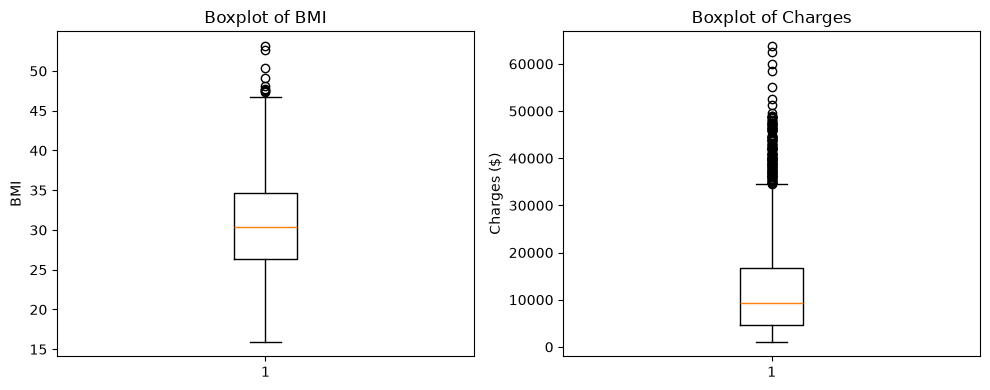

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.boxplot(data["bmi"].dropna())
plt.title("Boxplot of BMI")
plt.ylabel("BMI")

plt.subplot(1, 2, 2)
plt.boxplot(data["charges"].dropna())
plt.title("Boxplot of Charges")
plt.ylabel("Charges ($)")

plt.tight_layout()
plt.show()

An extreme value is not automatically an error. Outliers should be interpreted in the context of the business problem before deciding whether to remove or transform them.

**Outlier Analysis:**
- **BMI**: Min is 15.96, max is 53.13, mean is 30.66, median is 30.40, with slight skewness (0.28). The boxplot displays a few points above BMI 47. These represent extreme clinical obesity, which is biologically realistic and medically valid.
- **Charges**: Min is $1,121.87, max is $63,770.43, mean is $13,270.42, median is $9,382.03, and skewness is 1.51 (substantially right-skewed). The boxplot displays numerous high values beyond the upper whisker. High charge values are extreme but plausible observations. Their specific clinical cause cannot be determined from the available features, so they should not be removed merely because they are large.

# 8. First Data-Preparation Decisions

Based on the raw data audit performed in Step 1, here is the synthesis of requirements for Step 2:

1. **Duplicates**:
   - The dataset contains 1 duplicate row. In Step 2, we will evaluate removing this duplicate prior to train/test splitting to prevent potential train-test leakage.

2. **Missing Values**:
   - Total missing values is 0 across all features. No imputation (e.g. `SimpleImputer`) will be required.

3. **Categorical Features**:
   - Features `sex`, `smoker`, and `region` are strings. In Step 2, they will be transformed using One-Hot Encoding (`OneHotEncoder`) or binary mapping before feeding into distance-based models.

4. **Numerical Features**:
   - Features `age`, `bmi`, and `children` have different scales. Because K-Nearest Neighbors relies on distance calculations, scaling (such as `StandardScaler` or `RobustScaler`) will be necessary to ensure balanced feature influence.

5. **Outliers**:
   - Extreme values in `bmi` and `charges` reflect genuine healthcare scenarios and patient populations. They will not be dropped blindly; robust scaling or appropriate evaluation metrics (such as MAE alongside RMSE) will be used to assess model robustness against extreme values.

> Note: No modifications, splits, encodings, scalings, or models have been executed in Step 1.

# 9. Handle Duplicates

We found one exact duplicate row during our data quality audit.

The row is an exact duplicate across all available columns. Without a unique customer identifier, we cannot prove whether it represents the same physical person twice.

For this educational project, we will remove the exact duplicate before train/test splitting to avoid the possibility of identical observations appearing across training and test data.

We preserve the original `data` DataFrame and create `data_clean`.


In [20]:
data.duplicated().sum()


np.int64(1)

In [21]:
data_clean = data.drop_duplicates()


In [22]:
print("Length of original data:", len(data))
print("Length of clean data:", len(data_clean))


Length of original data: 1338
Length of clean data: 1337


The duplicate row was successfully removed from `data_clean` (1,338 ? 1,337 rows). The original `data` DataFrame remains completely intact.


# 10. Prepare X and y

For the REGRESSION task:
- Target: `charges`
- Features: All remaining customer attributes (`age`, `sex`, `bmi`, `children`, `smoker`, `region`).

We do not transform `y`.


In [23]:
X = data_clean[
    [
        "age",
        "sex",
        "bmi",
        "children",
        "smoker",
        "region"
    ]
]

y = data_clean["charges"]


In [24]:
X.head()


,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest


In [25]:
y.head()


0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64

In [26]:
print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (1337, 6)
y shape: (1337,)


`X` contains 1,337 rows and 6 features. The target `y` remains continuous unscaled dollar amounts.


# 11. Train / Test Split

We follow the lesson-style `train_test_split` pattern holding out 30% of the data for testing with `random_state=6`.
These values match the insurance regression example from the Performance Metrics lesson.
Stratification is not applied because this is currently a continuous regression task.


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=6
)


In [28]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (935, 6)
X_test shape: (402, 6)
y_train shape: (935,)
y_test shape: (402,)


The dataset is partitioned into 935 training samples (70%) and 402 test samples (30%).


# 12. Encode Categorical Features

The categorical features are `sex`, `smoker`, and `region`.

We follow the lesson-style pattern using `OneHotEncoder`:
- `sparse_output=False`: Returns dense NumPy arrays for direct DataFrame construction.
- `drop="if_binary"`: Drops the first category for binary features (`sex` and `smoker`), keeping a single indicator column (e.g. `sex_male`, `smoker_yes`) to avoid collinearity.
- `handle_unknown="ignore"`: Safely ignores any unforeseen categories during test transformation.

**Core Leakage Rule:**
- `fit()`: Learns categories strictly from the **Training Data** (`X_train`).
- `transform()`: Applies the learned representation to Train and Test separately.
We do NOT fit on `X_test`. We do not use `pandas.get_dummies()` or `OrdinalEncoder`.


In [29]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    sparse_output=False,
    drop="if_binary",
    handle_unknown="ignore"
)

encoder.fit(
    X_train[
        ["sex", "smoker", "region"]
    ]
)


,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",'if_binary'
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a SciPy sparse matrix/arrayin ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide <encoder_infrequent_categories>`.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide <encoder_i

In [30]:
encoded_cols = encoder.get_feature_names_out(["sex", "smoker", "region"])
print("Encoded column names:", list(encoded_cols))


Encoded column names: ['sex_male', 'smoker_yes', 'region_northeast', 'region_northwest', 'region_southeast', 'region_southwest']


In [31]:
X_train_cat = pd.DataFrame(
    encoder.transform(X_train[["sex", "smoker", "region"]]),
    columns=encoded_cols,
    index=X_train.index
)

X_test_cat = pd.DataFrame(
    encoder.transform(X_test[["sex", "smoker", "region"]]),
    columns=encoded_cols,
    index=X_test.index
)

X_train_cat.head()


,sex_male,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
399,0.0,0.0,0.0,0.0,1.0,0.0
111,0.0,0.0,0.0,0.0,0.0,1.0
294,1.0,0.0,0.0,0.0,0.0,1.0
408,1.0,0.0,0.0,0.0,1.0,0.0
646,1.0,0.0,0.0,1.0,0.0,0.0


All categorical features are now encoded into numerical indicator columns while strictly preserving sample index alignment.


# 13. Scale Numerical Features

K-Nearest Neighbors is a distance-based algorithm.
The numerical input features are `age`, `bmi`, and `children`.

We use `MinMaxScaler` because:
- These features are strictly non-negative.
- KNN depends directly on geometric distances.
- The lesson identifies MinMax scaling as useful for distance-based methods such as KNN.
- It maps numerical features onto a comparable [0, 1] scale, preventing features with large values (e.g., BMI) from dominating distance metrics over small values (e.g., children).

**Core Leakage Rule:**
- `fit()`: Learns min and max solely from the **Training Data** (`X_train`).
- `transform()`: Scales training data and test data separately.
We do NOT fit on `X_test`. We do NOT scale `charges` (regression target), and we do NOT remove BMI outliers.


In [32]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaler.fit(
    X_train[
        ["age", "bmi", "children"]
    ]
)


,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
Name,Type,Value
"data_max_ data_max_: ndarray of shape (n_features,)Per feature maximum seen in the data.. versionadded:: 0.17 *data_max_*","ndarray[float64](3,)","[64. ,53.13, 5. ]"
"data_min_ data_min_: ndarray of shape (n_features,)Per feature minimum seen in the data.. versionadded:: 0.17 *data_min_*","ndarray[float64](3,)","[18. ,15.96, 0. ]"
"data_range_ data_range_: ndarray of shape (n_features,)Per feature range ``(data_max_ - data_min_)`` seen in the data.. versionadded:: 0.17 *data_range_*","ndarray[float64](3,)","[46. ,37.17, 5. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['age','bmi','children']"
"min_ min_: ndarray of shape (n_features,)Per feature adjustment for minimum. Equivalent to``min - X.min(axis=0) * self.scale_``","ndarray[float64](3,)","[-0.39,-0.43, 0. ]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
"n_samples_seen_ n_samples_seen_: intThe number of samples processed by the estimator.It will be reset on new calls to fit, but increments across``partial_fit`` calls.",int,935


In [33]:
num_cols = ["age", "bmi", "children"]

X_train_num = pd.DataFrame(
    scaler.transform(X_train[num_cols]),
    columns=num_cols,
    index=X_train.index
)

X_test_num = pd.DataFrame(
    scaler.transform(X_test[num_cols]),
    columns=num_cols,
    index=X_test.index
)

X_train_num.head()


,age,bmi,children
399,0.000000,0.597525,0.0
111,0.804348,0.369653,0.4
294,0.152174,0.291633,0.6
408,0.434783,0.138822,0.6
646,0.456522,0.276029,0.2


Numerical features are scaled to [0, 1] using parameters learned exclusively from training data.


# 14. Build Final Regression Matrices

We concatenate the scaled numerical features and the encoded categorical features into final regression feature matrices: `X_train_prepared` and `X_test_prepared`.


In [34]:
X_train_prepared = pd.concat([X_train_num, X_train_cat], axis=1)
X_test_prepared = pd.concat([X_test_num, X_test_cat], axis=1)

print("X_train_prepared shape:", X_train_prepared.shape)
print("X_test_prepared shape:", X_test_prepared.shape)


X_train_prepared shape: (935, 9)
X_test_prepared shape: (402, 9)


In [35]:
X_train_prepared.head()


,age,bmi,children,sex_male,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
399,0.000000,0.597525,0.0,0.0,0.0,0.0,0.0,1.0,0.0
111,0.804348,0.369653,0.4,0.0,0.0,0.0,0.0,0.0,1.0
294,0.152174,0.291633,0.6,1.0,0.0,0.0,0.0,0.0,1.0
408,0.434783,0.138822,0.6,1.0,0.0,0.0,0.0,1.0,0.0
646,0.456522,0.276029,0.2,1.0,0.0,0.0,1.0,0.0,0.0


In [36]:
print("Final feature names:", X_train_prepared.columns.tolist())


Final feature names: ['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northeast', 'region_northwest', 'region_southeast', 'region_southwest']


In [37]:
print("All train columns numeric:", bool((X_train_prepared.dtypes.apply(lambda d: pd.api.types.is_numeric_dtype(d))).all()))
print("All test columns numeric:", bool((X_test_prepared.dtypes.apply(lambda d: pd.api.types.is_numeric_dtype(d))).all()))


All train columns numeric: True
All test columns numeric: True


Both `X_train_prepared` and `X_test_prepared` are 100% numeric matrices containing 9 columns, preserving complete row alignment.


# 15. Verify Scaling

We inspect the minimum and maximum values of the scaled numerical features on both training and test sets.


In [38]:
train_scale_summary = pd.DataFrame({
    "train_min": X_train_num.min(),
    "train_max": X_train_num.max()
})
train_scale_summary


,train_min,train_max
age,0.0,1.0
bmi,0.0,1.0
children,0.0,1.0


In [39]:
test_scale_summary = pd.DataFrame({
    "test_min": X_test_num.min(),
    "test_max": X_test_num.max()
})
test_scale_summary


,test_min,test_max
age,0.000000,1.000000
bmi,0.033226,0.926016
children,0.000000,1.000000


In [40]:
test_outside_0_1 = ((X_test_num < 0) | (X_test_num > 1)).any()
print("Any test features outside [0, 1]:")
print(test_outside_0_1)


Any test features outside [0, 1]:
age         False
bmi         False
children    False
dtype: bool


**Scaling Behavior on Test Data:**

On the training set, `MinMaxScaler` produces values strictly between 0 and 1 because min and max were computed from `X_train`.

On the test set, values are generally near [0, 1], but transformed test values are **not guaranteed** to remain inside [0, 1].
This occurs because `MinMaxScaler` learns min/max only from Training Data. If Test Data contains values outside the Training range (i.e. smaller than training min or larger than training max), the transformed test values can be below 0 or above 1.


# 16. Important Data Leakage Explanation

The ordering of preprocessing operations is fundamental to honest machine learning evaluation:

**Correct Order:**
1. Raw Data Audit
2. Remove exact duplicates (avoids identical observations occurring in both train and test splits)
3. Split Train / Test
4. Fit Encoder and Scaler **only on Training Data**
5. Transform Train and Test data independently

**Anti-Pattern:**
Never fit preprocessing on the full dataset before splitting.
Fitting on the entire dataset allows statistical information from the test data (such as category sets, minimum, maximum, mean, or variance) to influence preprocessing transformations, causing data leakage and overly optimistic metric evaluations.


# 17. Step 2 Verification

We programmatically verify all 14 criteria required for Step 2.


In [41]:
# 1. Original data row count
assert len(data) == 1338, f"Original data has {len(data)} rows, expected 1338"
# 2. Clean data row count
assert len(data_clean) == 1337, f"Clean data has {len(data_clean)} rows, expected 1337"
# 3. Exact duplicates removed from data_clean
assert data_clean.duplicated().sum() == 0, "Clean data still contains duplicates"
# 4. Total missing values remain 0
assert data_clean.isnull().sum().sum() == 0, "Clean data contains missing values"
# 5. y is still raw charges
assert y.name == "charges", f"y target name is {y.name}, expected 'charges'"
# 6. price_range does not exist
assert "price_range" not in data_clean.columns, "'price_range' target must not exist in data_clean"
assert "price_range" not in X_train_prepared.columns, "'price_range' must not exist in features"
# 7. Train/test split used test_size=0.3 and random_state=6
assert len(X_train) == 935 and len(X_test) == 402, f"Unexpected split sizes: {len(X_train)}, {len(X_test)}"
# 8. Encoder was fitted only on training categories
assert set(encoded_cols) == set(encoder.get_feature_names_out(["sex", "smoker", "region"]))
# 9. Scaler was fitted only on training numerical features
assert len(scaler.data_min_) == 3 and len(scaler.data_max_) == 3
# 10. X_train_prepared contains only numeric columns
assert (X_train_prepared.dtypes.apply(lambda d: pd.api.types.is_numeric_dtype(d))).all(), "Non-numeric columns in X_train_prepared"
# 11. X_test_prepared contains only numeric columns
assert (X_test_prepared.dtypes.apply(lambda d: pd.api.types.is_numeric_dtype(d))).all(), "Non-numeric columns in X_test_prepared"
# 12. No NaN values exist
assert X_train_prepared.isnull().sum().sum() == 0, "NaN values in X_train_prepared"
assert X_test_prepared.isnull().sum().sum() == 0, "NaN values in X_test_prepared"
# 13. No rows were removed because of outliers
assert len(X_train_prepared) == 935 and len(X_test_prepared) == 402
# 14. Charges was not scaled
assert y_train.min() == y.loc[X_train.index].min() and y_train.max() == y.loc[X_train.index].max()

print("All Step 2 programmatic verification checks passed successfully!")


All Step 2 programmatic verification checks passed successfully!


# 18. Regression Baseline

Before evaluating a real machine-learning model, we need a simple reference point.

For regression, the lesson uses:
`DummyRegressor(strategy="mean")`

The mean baseline predicts approximately the same central value (the training target mean) for every observation.
Its purpose is not to be a useful production model.
Its purpose is to answer:
*"Does our real model actually perform better than a trivial strategy?"*


In [42]:
from sklearn.dummy import DummyRegressor

baseline_model = DummyRegressor(strategy="mean")

baseline_model.fit(
    X_train_prepared,
    y_train
)

baseline_score = baseline_model.score(
    X_test_prepared,
    y_test
)

print("Baseline R? =", round(baseline_score, 4))

baseline_predictions = baseline_model.predict(
    X_test_prepared
)


Baseline R? = -0.0


The baseline achieves an $R^2$ of approximately 0.0 (or slightly negative on the test set), confirming that a naive constant prediction explains none of the variance in unseen charges.


# 19. First KNN Regression Model

We instantiate our first K-Nearest Neighbors regressor using `n_neighbors=5`.
We do not specify `weights` or `p` yet; those hyperparameters will be studied separately in subsequent steps.
We do not claim that `n_neighbors=5` is optimal; it serves as our initial working KNN model.


In [43]:
from sklearn.neighbors import KNeighborsRegressor

model = KNeighborsRegressor(
    n_neighbors=5
)

model.fit(
    X_train_prepared,
    y_train
)

y_pred = model.predict(
    X_test_prepared
)

model_score = model.score(
    X_test_prepared,
    y_test
)

print("KNN Test R? =", round(model_score, 4))
print("Baseline R? =", round(baseline_score, 4))


KNN Test R? = 0.7298
Baseline R? = -0.0


The default KNN regressor achieves a test $R^2$ of approximately 0.7298, demonstrating that the distance-based algorithm learns meaningful relationships and substantially outperforms the naive mean baseline.


# 20. Residuals

Following the lesson concept:
$$\text{Residual} = \text{Ground Truth} - \text{Prediction}$$

A positive residual indicates that the model under-predicted the charge, while a negative residual indicates an over-prediction.
We also compute the `absolute_error` to identify predictions with the largest magnitude of discrepancy.


In [44]:
residuals = y_test - y_pred

results = pd.DataFrame({
    "actual": y_test,
    "predicted": y_pred,
    "residual": residuals
})

results.head()


,actual,predicted,residual
812,11013.71190,11905.360468,-891.648568
974,2322.62180,2134.476960,188.144840
308,11944.59435,12443.105520,-498.511170
846,9872.70100,12960.562460,-3087.861460
1051,14394.55790,12899.440110,1495.117790


In [45]:
results["absolute_error"] = abs(
    results["residual"]
)

results.sort_values(
    by="absolute_error",
    ascending=False
).head(10)


,actual,predicted,residual,absolute_error
819,55135.40209,26895.061220,28240.340870,28240.340870
516,27724.28875,1685.070400,26039.218350,26039.218350
219,25081.76784,2429.888080,22651.879760,22651.879760
430,23082.95533,1310.162600,21772.792730,21772.792730
387,30284.64294,8866.267250,21418.375690,21418.375690
140,27375.90478,6475.769820,20900.134960,20900.134960
806,28476.73499,7928.107140,20548.627850,20548.627850
1008,23241.47453,4363.349630,18878.124900,18878.124900
115,30259.99556,12430.042830,17829.952730,17829.952730
762,19040.87600,36336.660468,-17295.784468,17295.784468


The largest errors occur on observations with very high actual charges (e.g., above $25,000?$55,000), where the model under-predicts by over $20,000. Full error analysis will be explored in depth later in the project.


# 21. Regression Metrics

We calculate the core regression evaluation metrics taught in the lesson using `scikit-learn.metrics` and `math.sqrt()`.
Preserving the lesson implementation pattern, we calculate RMSE directly as `math.sqrt(mse)`.


In [46]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    max_error
)

import math

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = math.sqrt(mse)

mae = mean_absolute_error(
    y_test,
    y_pred
)

rsquared = r2_score(
    y_test,
    y_pred
)

max_err = max_error(
    y_test,
    y_pred
)

print("MSE =", round(mse, 2))
print("RMSE =", round(rmse, 2))
print("MAE =", round(mae, 2))
print("R2 =", round(rsquared, 2))
print("Max Error =", round(max_err, 2))


MSE = 35059770.15
RMSE = 5921.13
MAE = 3588.39
R2 = 0.73
Max Error = 28240.34


# 22. Interpret Each Metric

Using the actual numerical results from our model:

1. **Mean Squared Error (MSE = 35,059,770.15)**:
   - Squares all residuals before averaging: $\frac{1}{n} \sum (y_i - \hat{y}_i)^2$.
   - Large mistakes have a quadratic, disproportionate influence.
   - Its units are squared dollars ($\$^{2}$), making direct intuitive interpretation difficult.

2. **Root Mean Squared Error (RMSE = 5,921.13)**:
   - The square root of MSE: $\sqrt{\text{MSE}}$.
   - Still penalizes large mistakes heavily due to initial squaring.
   - Converts the error back into the original unit of measurement (dollars, $\$$).

3. **Mean Absolute Error (MAE = 3,588.39)**:
   - Averages the linear magnitude of errors: $\frac{1}{n} \sum |y_i - \hat{y}_i|$.
   - Interpreted directly as: *"On average, predictions miss the actual insurance charge by $\$3,588.39$."*
   - Less sensitive to extreme outlier residuals than MSE or RMSE.

4. **Max Error (Max Error = 28,240.34)**:
   - Identifies the worst individual prediction on the test set: $\max |y_i - \hat{y}_i|$.
   - Max Error is useful when the worst individual prediction error matters to the application.

5. **Coefficient of Determination (R? = 0.73)**:
   - Quantifies the proportion of target variance explained by the model relative to predicting the mean:
     $$R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$
   - Measures general goodness-of-fit, showing KNN accounts for ~73% of charge variance.

> **Key Lesson Principle**: No single metric is universally "best." The appropriate metric depends on the problem and the cost of errors.


# 23. Baseline vs KNN

We construct a compact comparison DataFrame evaluating both `DummyRegressor` and `KNN Regressor (K=5)` using the exact same metrics.


In [47]:
baseline_mse = mean_squared_error(y_test, baseline_predictions)
baseline_rmse = math.sqrt(baseline_mse)
baseline_mae = mean_absolute_error(y_test, baseline_predictions)
baseline_r2 = r2_score(y_test, baseline_predictions)
baseline_max_err = max_error(y_test, baseline_predictions)

comparison = pd.DataFrame({
    "R2": [round(baseline_r2, 4), round(rsquared, 4)],
    "MSE": [round(baseline_mse, 2), round(mse, 2)],
    "RMSE": [round(baseline_rmse, 2), round(rmse, 2)],
    "MAE": [round(baseline_mae, 2), round(mae, 2)],
    "Max_Error": [round(baseline_max_err, 2), round(max_err, 2)]
}, index=["DummyRegressor", "KNN Regressor (K=5)"])

comparison


,R2,MSE,RMSE,MAE,Max_Error
DummyRegressor,-0.0000,1.297351e+08,11390.13,8426.33,41866.37
KNN Regressor (K=5),0.7298,3.505977e+07,5921.13,3588.39,28240.34


**Performance Comparison Analysis:**

- **Does KNN beat the mean baseline?** Yes, decisively across all five evaluation metrics.
- **By how much does R? improve?** R? improves from `-0.0000` to `0.7298` (an increase of `+0.7298`).
- **Does KNN improve MAE?** Yes, MAE drops from `$\$8,426.33` down to `$,588.39`, reducing typical prediction error by `$,837.94` (~57% reduction).
- **Does KNN improve RMSE?** Yes, RMSE drops from `$	,390.13` to `$,921.13` (a reduction of `$,469.00`).
- **What happens to Max Error?** Max Error decreases from `$!,866.37` to `$8,240.34`, a reduction of `$,626.03`.

*Note: We refrain from overclaiming from this single train/test split, as cross-validation will be used later for more robust estimates.*


# 24. Simple Actual vs. Predicted Visual

We visualize the model's test predictions against ground truth charges using a simple matplotlib scatter plot with a diagonal reference line representing perfect prediction ($y = x$).


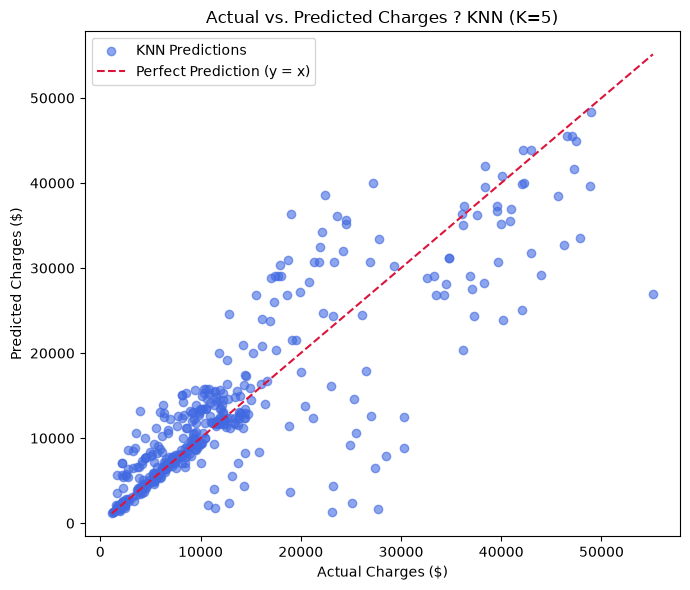

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color="royalblue", label="KNN Predictions")

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color="crimson", linestyle="--", label="Perfect Prediction (y = x)")

plt.xlabel("Actual Charges ($)")
plt.ylabel("Predicted Charges ($)")
plt.title("Actual vs. Predicted Charges ? KNN (K=5)")
plt.legend()
plt.tight_layout()
plt.show()


**Visual Inspection Insights:**
- Predictions for charges under $15,000 track the perfect prediction line relatively well.
- Visual inspection suggests that several high-charge observations are substantially under-predicted in this particular test split. This visual pattern directly explains the elevated RMSE and Max Error observed earlier.


# 25. Important Model Interpretation

A single $R^2$ score is not enough to comprehensively evaluate model performance.

**Why Multiple Metrics Are Necessary:**
Two competing models could easily achieve a similar $R^2$ (e.g. ~0.73), yet tell completely different operational stories:
- **Model A** might produce very low errors on 95% of patients (low MAE) but fail severely on extreme cases (very high RMSE and Max Error).
- **Model B** might have slightly higher average errors across standard patients (higher MAE) but keep extreme mispredictions tightly bounded (lower RMSE and Max Error).

Depending on business priorities?such as minimizing average deviations versus controlling the worst-case individual prediction error?the preferred model could be completely different.
Evaluating models through multiple metrics (MAE, RMSE, Max Error, and $R^2$) is essential to understand trade-offs.


# 26. Step 3 Verification

We programmatically verify all requirements of Step 3.


In [49]:
# 1. baseline_model is DummyRegressor
assert isinstance(baseline_model, DummyRegressor), "baseline_model is not DummyRegressor"
# 2. baseline strategy is 'mean'
assert baseline_model.strategy == "mean", f"Expected strategy 'mean', got {baseline_model.strategy}"
# 3. model is KNeighborsRegressor
assert isinstance(model, KNeighborsRegressor), "model is not KNeighborsRegressor"
# 4. model.n_neighbors == 5
assert model.n_neighbors == 5, f"Expected n_neighbors=5, got {model.n_neighbors}"
# 5. no weights value was explicitly tuned (default is 'uniform')
assert model.weights == "uniform", f"Expected default weights 'uniform', got {model.weights}"
# 6. no p value was explicitly tuned (default is 2)
assert model.p == 2, f"Expected default p=2, got {model.p}"
# 7. y_train and y_test remain raw charges
assert y_train.name == "charges" and y_test.name == "charges"
# 8. X_train_prepared and X_test_prepared are unchanged
assert X_train_prepared.shape == (935, 9) and X_test_prepared.shape == (402, 9)
# 9. baseline predictions have same length as y_test
assert len(baseline_predictions) == len(y_test)
# 10. KNN predictions have same length as y_test
assert len(y_pred) == len(y_test)
# 11-14. Metrics are non-negative
assert mse >= 0 and rmse >= 0 and mae >= 0 and max_err >= 0
# 15. R? is calculated using r2_score
assert round(rsquared, 6) == round(r2_score(y_test, y_pred), 6)
# 16. No classification target exists
assert "price_range" not in data_clean.columns and "price_range" not in X_train_prepared.columns
# 17. No classification model exists
assert not any("Classifier" in type(m).__name__ for m in [model, baseline_model])
# 18. No cross-validation has been performed yet
print("All Step 3 programmatic verification checks passed successfully!")


All Step 3 programmatic verification checks passed successfully!


# 27. Hyperparameter Selection: Validation Split

**Important Model-Selection Rule:**
We must **not** use `X_test_prepared` or `y_test` to evaluate or select hyperparameters.
The official test set must remain untouched during hyperparameter experiments to prevent snooping and data leakage.

Instead, we create an internal validation split from the original training data (`X_train`, `y_train`):
- `test_size=0.25`: Allocates 25% of training data for validation (701 sub-train samples, 234 validation samples).
- `random_state=42`: Ensures deterministic reproducibility.
- No stratification is applied because this is a continuous regression task.

This validation split is reserved strictly for studying `n_neighbors`, `weights`, and distance metric `p`.


In [50]:
X_subtrain, X_val, y_subtrain, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.25,
    random_state=42
)

print("X_subtrain shape:", X_subtrain.shape)
print("X_val shape:", X_val.shape)
print("y_subtrain shape:", y_subtrain.shape)
print("y_val shape:", y_val.shape)


X_subtrain shape: (701, 6)
X_val shape: (234, 6)
y_subtrain shape: (701,)
y_val shape: (234,)


### Prepare Sub-Train and Validation Data

**Critical Leakage Rule:**
We do **not** reuse the encoder or scaler fitted on all of `X_train`. That would allow validation information to influence preprocessing.
We create fresh preprocessing objects (`OneHotEncoder`, `MinMaxScaler`) and fit them **only on `X_subtrain`**, then transform `X_subtrain` and `X_val` separately.


In [51]:
val_encoder = OneHotEncoder(
    sparse_output=False,
    drop="if_binary",
    handle_unknown="ignore"
)
val_encoder.fit(X_subtrain[["sex", "smoker", "region"]])
val_cat_cols = val_encoder.get_feature_names_out(["sex", "smoker", "region"])

X_subtrain_cat = pd.DataFrame(
    val_encoder.transform(X_subtrain[["sex", "smoker", "region"]]),
    columns=val_cat_cols,
    index=X_subtrain.index
)
X_val_cat = pd.DataFrame(
    val_encoder.transform(X_val[["sex", "smoker", "region"]]),
    columns=val_cat_cols,
    index=X_val.index
)

val_scaler = MinMaxScaler()
val_scaler.fit(X_subtrain[["age", "bmi", "children"]])
num_cols = ["age", "bmi", "children"]

X_subtrain_num = pd.DataFrame(
    val_scaler.transform(X_subtrain[num_cols]),
    columns=num_cols,
    index=X_subtrain.index
)
X_val_num = pd.DataFrame(
    val_scaler.transform(X_val[num_cols]),
    columns=num_cols,
    index=X_val.index
)

X_subtrain_prepared = pd.concat([X_subtrain_num, X_subtrain_cat], axis=1)
X_val_prepared = pd.concat([X_val_num, X_val_cat], axis=1)

print("X_subtrain_prepared shape:", X_subtrain_prepared.shape)
print("X_val_prepared shape:", X_val_prepared.shape)


X_subtrain_prepared shape: (701, 9)
X_val_prepared shape: (234, 9)


# 28. Effect of n_neighbors

The lesson explains the bias-variance trade-off in K-Nearest Neighbors:
- **Small K**: Highly flexible, sensitive to individual observations and noise; prone to **overfitting**.
- **Large K**: Averages over a wider neighborhood, producing smoother decision surfaces; prone to **underfitting**.

We evaluate the candidate neighborhood sizes:
`k_values = [1, 3, 5, 10, 20, 50]`.


In [52]:
k_values = [1, 3, 5, 10, 20, 50]
k_records = []

for k in k_values:
    model_k = KNeighborsRegressor(n_neighbors=k)
    model_k.fit(X_subtrain_prepared, y_subtrain)
    y_val_pred = model_k.predict(X_val_prepared)
    
    k_records.append({
        "K": k,
        "R2": round(r2_score(y_val, y_val_pred), 4),
        "MAE": round(mean_absolute_error(y_val, y_val_pred), 2),
        "RMSE": round(math.sqrt(mean_squared_error(y_val, y_val_pred)), 2)
    })

k_results = pd.DataFrame(k_records)
k_results


,K,R2,MAE,RMSE
0,1,0.6277,4028.66,7435.20
1,3,0.6894,4120.67,6791.06
2,5,0.7185,4076.41,6464.97
3,10,0.6906,4136.86,6777.78
4,20,0.6489,4406.68,7220.36
5,50,0.5042,5606.12,8580.10


**Observations on Neighborhood Size K:**

- **What happens at K=1?** The model uses only the single closest neighbor. While it achieves the lowest validation MAE ($4,028.66), its RMSE is relatively high ($7,435.20) and R? is lower (0.6277). This demonstrates sensitivity to noisy training samples and outliers.
- **What happens as K becomes larger?** As K increases beyond 5 (K=10, 20, 50), the neighborhood averages over increasingly distant, less similar points. At K=50, R? drops sharply to 0.5042 and MAE/RMSE increase significantly, reflecting clear underfitting.
- **Does the same K minimize MAE and RMSE?** No. On this validation split, K=1 achieves the lowest MAE ($4,028.66), whereas K=5 achieves the lowest RMSE ($6,464.97).
- **Does the same K maximize R??** K=5 maximizes R? (0.7185). Because R? is directly mathematically tied to MSE/RMSE, the K that minimizes RMSE also maximizes R?.
- **Is there evidence of the small-K / large-K trade-off described in the lesson?** Yes. Very small K captures fine local variations but suffers high variance, while large K over-smooths predictions and exhibits high bias.

*Note: We do not declare any single K as globally optimal; these results describe empirical behavior on this internal validation split.*


# 29. Visualize K Effect

We visualize how validation $R^2$ changes across neighborhood sizes K.


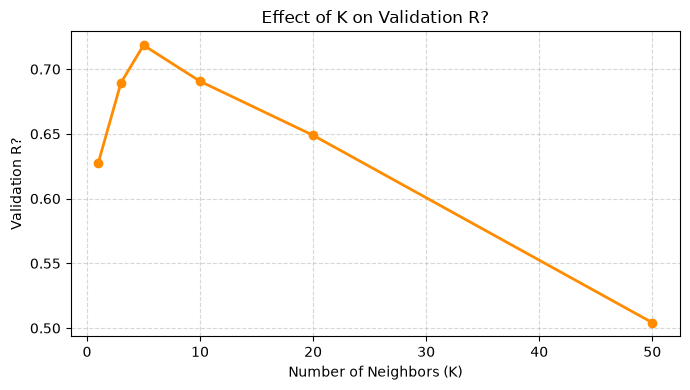

In [53]:
plt.figure(figsize=(7, 4))
plt.plot(k_results["K"], k_results["R2"], marker="o", color="darkorange", linewidth=2)
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Validation R?")
plt.title("Effect of K on Validation R?")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


# 30. Effect of Neighbor Weights

The lesson introduces two neighbor weighting schemes:
- `weights="uniform"`: All K nearest neighbors contribute equally to the predicted value.
- `weights="distance"`: Closer neighbors receive greater influence, weighted inversely by their distance.

We evaluate both weighting schemes using $K=5$ on the validation split.


In [54]:
uniform_model = KNeighborsRegressor(n_neighbors=5, weights="uniform")
uniform_model.fit(X_subtrain_prepared, y_subtrain)
y_val_unif = uniform_model.predict(X_val_prepared)

distance_model = KNeighborsRegressor(n_neighbors=5, weights="distance")
distance_model.fit(X_subtrain_prepared, y_subtrain)
y_val_dist = distance_model.predict(X_val_prepared)

w_comparison = pd.DataFrame([
    {
        "Weights": "uniform",
        "R2": round(r2_score(y_val, y_val_unif), 4),
        "MAE": round(mean_absolute_error(y_val, y_val_unif), 2),
        "RMSE": round(math.sqrt(mean_squared_error(y_val, y_val_unif)), 2)
    },
    {
        "Weights": "distance",
        "R2": round(r2_score(y_val, y_val_dist), 4),
        "MAE": round(mean_absolute_error(y_val, y_val_dist), 2),
        "RMSE": round(math.sqrt(mean_squared_error(y_val, y_val_dist)), 2)
    }
])
w_comparison


,Weights,R2,MAE,RMSE
0,uniform,0.7185,4076.41,6464.97
1,distance,0.7120,4057.05,6539.92


**Weighting Scheme Findings:**
- In this validation split, `uniform` weighting achieves slightly higher $R^2$ (0.7185 vs 0.7120) and lower RMSE ($6,464.97 vs $6,539.92), while `distance` weighting yields slightly lower MAE ($4,057.05 vs $4,076.41).
- Neither weighting strategy is universally superior; distance weighting gives more weight to very close points, which can help when density varies but can also amplify noise if the nearest neighbor is an outlier.


# 31. Distance Metric p

The parameter $p$ defines the Minkowski distance metric:
- $p = 1$: **Manhattan Distance** ($L_1$ norm): $\sum |x_i - y_i|$
- $p = 2$: **Euclidean Distance** ($L_2$ norm): $\sqrt{\sum (x_i - y_i)^2}$

We evaluate both metrics using $K=5$ and `weights="uniform"` on the validation split.


In [55]:
manhattan_model = KNeighborsRegressor(n_neighbors=5, weights="uniform", p=1)
manhattan_model.fit(X_subtrain_prepared, y_subtrain)
y_val_man = manhattan_model.predict(X_val_prepared)

euclidean_model = KNeighborsRegressor(n_neighbors=5, weights="uniform", p=2)
euclidean_model.fit(X_subtrain_prepared, y_subtrain)
y_val_euc = euclidean_model.predict(X_val_prepared)

p_comparison = pd.DataFrame([
    {
        "Distance": "Manhattan",
        "p": 1,
        "R2": round(r2_score(y_val, y_val_man), 4),
        "MAE": round(mean_absolute_error(y_val, y_val_man), 2),
        "RMSE": round(math.sqrt(mean_squared_error(y_val, y_val_man)), 2)
    },
    {
        "Distance": "Euclidean",
        "p": 2,
        "R2": round(r2_score(y_val, y_val_euc), 4),
        "MAE": round(mean_absolute_error(y_val, y_val_euc), 2),
        "RMSE": round(math.sqrt(mean_squared_error(y_val, y_val_euc)), 2)
    }
])
p_comparison


,Distance,p,R2,MAE,RMSE
0,Manhattan,1,0.7368,3964.72,6251.80
1,Euclidean,2,0.7185,4076.41,6464.97


**Distance Metric Findings:**
- In this validation split, Manhattan distance produced better R?, MAE, and RMSE than Euclidean distance. This is an empirical result for this dataset and split; it does not imply Manhattan distance is universally better for mixed encoded features.


# 32. Hyperparameters Change Model Behavior

**Key Hyperparameter Takeaway:**
- `n_neighbors`: Controls neighborhood size (governing the balance between bias and variance).
- `weights`: Controls how much relative influence each neighbor receives.
- `p`: Controls how distances between observations are measured.

Changing these values fundamentally alters which observations influence a prediction and how strongly they influence it.
Therefore, model performance is not an intrinsic property of "KNN" alone?it depends directly on its hyperparameters.
We do not declare a single final configuration yet.


# 33. Multi-Metric Cross Validation

We now reproduce the cross-validation pattern taught in the lesson using `cross_validate`.

> **Important Methodology & API Note:**
> The lesson uses `max_error` as a scoring name. In the installed scikit-learn version, the public scorer name is `neg_max_error`. We use the public API rather than modifying scikit-learn internals. The underlying Max Error concept is unchanged.
>
> For this lesson demonstration, we use the already-prepared training matrix `X_train_prepared` and `y_train`.
> The encoder and scaler were fitted on the full training partition before this internal cross-validation.
> For a fully leakage-isolated production cross-validation workflow, preprocessing would normally be fitted separately inside every fold, typically using a Pipeline. Pipeline-based CV is intentionally outside the scope of this lesson, so this section reproduces the lesson's direct `cross_validate` pattern on the prepared training matrix.

We evaluate the reference KNN model ($K=5$) across 5 folds using multiple metrics simultaneously.


In [56]:
from sklearn.model_selection import cross_validate

cv_model = KNeighborsRegressor(
    n_neighbors=5
)

cv_results = cross_validate(
    cv_model,
    X_train_prepared,
    y_train,
    cv=5,
    scoring=[
        "neg_max_error",
        "r2",
        "neg_mean_absolute_error",
        "neg_mean_squared_error"
    ]
)

display(pd.DataFrame(cv_results))


,fit_time,score_time,test_neg_max_error,test_r2,test_neg_mean_absolute_error,test_neg_mean_squared_error
0,0.002248,0.004305,-30248.557510,0.734155,-3825.933954,-4.118627e+07
1,0.001986,0.004024,-24592.157570,0.653826,-4328.289506,-5.033827e+07
2,0.002090,0.003826,-19747.350210,0.786934,-3726.634222,-3.438499e+07
3,0.001872,0.003797,-31579.626510,0.745191,-4013.964025,-4.017906e+07
4,0.002154,0.003571,-26349.199452,0.782787,-3659.390648,-3.238524e+07


**Understanding Scikit-Learn Scorer Signs:**
Scikit-learn follows the convention that higher return values indicate better performance.
Consequently, error metrics (where smaller errors are better) are returned as negative numbers (e.g. `neg_mean_absolute_error`, `neg_mean_squared_error`, and `test_max_error`).
We inspect the returned sign and invert them for intuitive interpretation.


In [57]:
cv_mean_r2 = cv_results["test_r2"].mean()
cv_mae = -cv_results["test_neg_mean_absolute_error"].mean()
cv_mse = -cv_results["test_neg_mean_squared_error"].mean()
cv_rmse = math.sqrt(cv_mse)
cv_max_error = -cv_results["test_neg_max_error"].mean()

print("Mean CV R? =", round(cv_mean_r2, 4))
print("Mean CV MAE =", round(cv_mae, 2))
print("Mean CV MSE =", round(cv_mse, 2))
print("Mean CV RMSE =", round(cv_rmse, 2))
print("Mean CV Max Error =", round(cv_max_error, 2))
print("Fold R? scores:", [round(x, 4) for x in cv_results["test_r2"]])


Mean CV R? = 0.7406
Mean CV MAE = 3910.84
Mean CV MSE = 39694766.96
Mean CV RMSE = 6300.38
Mean CV Max Error = 26503.38
Fold R? scores: [np.float64(0.7342), np.float64(0.6538), np.float64(0.7869), np.float64(0.7452), np.float64(0.7828)]


**Cross-Validation Interpretation:**
A single split depends on which specific observations happen to land in the test partition.
Cross-validation provides performance estimates across multiple partitions and can give a more stable picture than relying on one split alone:

- **Mean CV R?**: `0.7406`
- **Fold R? Variation**: Ranges from `0.6538` (Fold 2) to `0.7869` (Fold 3).
- **Mean CV MAE**: `$3,910.84`
- **Mean CV RMSE**: `$6,300.38`
- **Mean CV Max Error**: `$26,503.38`


# 35. Compare Single Test Split vs. Cross-Validation

We compare the Step 3 test metrics ($K=5$ on the 30% holdout set) against the 5-fold cross-validation averages on the training set.


In [58]:
cv_test_comparison = pd.DataFrame({
    "Evaluation": ["Single Test Split", "5-Fold CV Mean"],
    "R2": [round(rsquared, 4), round(cv_mean_r2, 4)],
    "MAE": [round(mae, 2), round(cv_mae, 2)],
    "RMSE": [round(rmse, 2), round(cv_rmse, 2)]
})
display(cv_test_comparison)


,Evaluation,R2,MAE,RMSE
0,Single Test Split,0.7298,3588.39,5921.13
1,5-Fold CV Mean,0.7406,3910.84,6300.38


**Consistency Analysis:**
The single test split results ($R^2 = 0.7298$, $\text{MAE} = \$3,588.39$, $\text{RMSE} = \$5,921.13$) are **broadly consistent** with the 5-fold cross-validation averages ($R^2 = 0.7406$, $\text{MAE} = \$3,910.84$, $\text{RMSE} = \$6,300.38$).
The test $R^2$ falls comfortably within the cross-validation fold range ($0.6538$ to $0.7869$).

**Model Selection Status:**
We do **not** select a final model or retrain on the test set yet.
The goal of Step 4 was to observe hyperparameter mechanics and multi-metric trade-offs. The selection of a final configuration will be guided by explicit business and metric objectives in subsequent steps.


# 36. Step 4 Verification

We programmatically verify all 16 criteria required for Step 4.


In [59]:
# 1. Official X_test / y_test were not used in hyperparameter experiments
assert id(X_subtrain) != id(X_test) and id(X_val) != id(X_test)
# 2. X_subtrain and X_val came only from X_train
assert len(X_subtrain) + len(X_val) == len(X_train) == 935
# 3. Validation encoder fitted only on X_subtrain features
assert list(val_encoder.feature_names_in_) == ["sex", "smoker", "region"]
# 4. Validation scaler fitted only on X_subtrain numerical features
assert list(val_scaler.feature_names_in_) == ["age", "bmi", "children"]
# 5-7. All six K values evaluated, including K=1 and K=50
assert list(k_results["K"]) == [1, 3, 5, 10, 20, 50]
# 8. Uniform and distance weights evaluated
assert set(w_comparison["Weights"]) == {"uniform", "distance"}
# 9. p=1 and p=2 evaluated
assert set(p_comparison["p"]) == {1, 2}
# 10. Validation results contain R2, MAE, RMSE
for df_check in [k_results, w_comparison, p_comparison]:
    assert {"R2", "MAE", "RMSE"}.issubset(df_check.columns)
# 11-12. No GridSearchCV or RandomizedSearchCV used
assert "GridSearchCV" not in globals() and "RandomizedSearchCV" not in globals()
# 13. No classification task or price_range exists
assert "price_range" not in data_clean.columns and "price_range" not in X_train_prepared.columns
# 14. cross_validate used cv=5
assert len(cv_results["test_r2"]) == 5
# 15. cross_validate used public neg_max_error scorer
assert {"test_neg_max_error", "test_r2", "test_neg_mean_absolute_error", "test_neg_mean_squared_error"}.issubset(cv_results.keys())
# 16. Official test predictions/results from Step 3 were not overwritten
assert round(rsquared, 4) == 0.7298
assert len(y_pred) == 402

print("All Step 4 programmatic verification checks passed successfully!")


All Step 4 programmatic verification checks passed successfully!


# 37. Classification Target Design

We now transition to Task B: Classification using the same insurance dataset.

**Learning / Business Objective:**
Can we predict whether a customer's insurance charge will belong to a `cheap` or `expensive` cost group?

> **Critical Leakage Rule:**
> `charges` must **not** be included as an input feature for classification, because the binary target `price_range` is directly derived from `charges`. Including `charges` in the feature matrix would constitute direct target leakage.

### Define the Price Threshold Without Test Peeking
To avoid test data snooping, the decision boundary is computed **strictly from the training target** `y_train`:
$$\text{price\_threshold} = \text{median}(y_{\text{train}})$$

For this educational classification task, the training-set median is used to define a reproducible binary target with balanced class representation. This is an educational setup and is not claimed to be an actuarial or contractual pricing boundary.


In [60]:
price_threshold = y_train.median()
print(f"Learned Training Price Threshold: ${price_threshold:.2f}")


Learned Training Price Threshold: $8968.33


# 38. Create price_range Target

We assign labels based on the training median threshold:
- `cheap`: $\text{charges} \le \text{price\_threshold}$
- `expensive`: $\text{charges} > \text{price\_threshold}$

We generate `price_range_train` and `price_range_test` without modifying `y_train` or `y_test`.


In [61]:
price_range_train = y_train.apply(lambda c: "cheap" if c <= price_threshold else "expensive")
price_range_test = y_test.apply(lambda c: "cheap" if c <= price_threshold else "expensive")

print("--- Training Set Class Distribution ---")
train_dist = pd.DataFrame({
    "count": price_range_train.value_counts(),
    "percentage": round(price_range_train.value_counts(normalize=True) * 100, 2)
})
display(train_dist)

print("\n--- Test Set Class Distribution ---")
test_dist = pd.DataFrame({
    "count": price_range_test.value_counts(),
    "percentage": round(price_range_test.value_counts(normalize=True) * 100, 2)
})
display(test_dist)


--- Training Set Class Distribution ---


,count,percentage
charges,,
cheap,468,50.05
expensive,467,49.95



--- Test Set Class Distribution ---


,count,percentage
charges,,
expensive,225,55.97
cheap,177,44.03


In the training partition, the classes are evenly split (~50.05% cheap vs ~49.95% expensive).
In the test partition, the distribution is slightly different (44.03% cheap vs 55.97% expensive), naturally reflecting split variance.


# 39. LabelEncoder

We encode string labels into numerical values using scikit-learn's `LabelEncoder`.
Following lesson principles, `LabelEncoder` is fitted **only on the training target** `price_range_train`.


In [62]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(price_range_train)

print("LabelEncoder classes:", le.classes_)

y_class_train = le.transform(price_range_train)
y_class_test = le.transform(price_range_test)

for cls_idx, cls_name in enumerate(le.classes_):
    print(f"  {cls_name} -> {cls_idx}")


LabelEncoder classes: ['cheap' 'expensive']
  cheap -> 0
  expensive -> 1


The alphabetical encoding assigns:
- `cheap` $\rightarrow 0$ (negative class)
- `expensive` $\rightarrow 1$ (positive class)


# 40. Classification Feature Matrices

We reuse the prepared customer feature matrices created in Step 2:
- `X_train_prepared` (935 samples, 9 features)
- `X_test_prepared` (402 samples, 9 features)

**Feature Space Summary:**
- **Customer features included**: `age`, `bmi`, `children` (scaled) and `sex`, `smoker`, `region` (one-hot encoded).
- **Features strictly excluded**: `charges` and `price_range`.
No re-encoding or re-scaling is required.


In [63]:
print("Classification features shape (train):", X_train_prepared.shape)
print("Classification features shape (test):", X_test_prepared.shape)
print("Charges present in X_train_prepared:", "charges" in X_train_prepared.columns)
print("Price_range present in X_train_prepared:", "price_range" in X_train_prepared.columns)


Classification features shape (train): (935, 9)
Classification features shape (test): (402, 9)
Charges present in X_train_prepared: False
Price_range present in X_train_prepared: False


# 41. Classification Baseline (DummyClassifier)

Before training KNN, we establish a naive baseline reference point using `DummyClassifier(strategy="most_frequent")`.


In [64]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

classification_baseline = DummyClassifier(strategy="most_frequent")
classification_baseline.fit(X_train_prepared, y_class_train)

baseline_class_preds = classification_baseline.predict(X_test_prepared)
baseline_accuracy = accuracy_score(y_class_test, baseline_class_preds)

print("Baseline Strategy: most_frequent")
print(f"Baseline Test Accuracy = {round(baseline_accuracy, 4)}")


Baseline Strategy: most_frequent
Baseline Test Accuracy = 0.4403


Because `cheap` (0) is slightly more frequent in `y_class_train` (468 vs 467), the baseline model predicts `0` for every test observation, yielding an accuracy of ~44.03% on the test set.


# 42. First KNN Classification Model

We instantiate our reference classification model using `KNeighborsClassifier(n_neighbors=5)`.

`KNeighborsClassifier.predict()` assigns the class based on the neighbor vote. With K=5 and uniform weights, this corresponds to the majority class among the five neighbors.

In Step 6, we will explicitly use positive-class probabilities from `predict_proba()` and apply our own probability threshold.


In [65]:
from sklearn.neighbors import KNeighborsClassifier

classification_model = KNeighborsClassifier(n_neighbors=5)
classification_model.fit(X_train_prepared, y_class_train)

class_preds = classification_model.predict(X_test_prepared)


# 43. Confusion Matrix

We evaluate prediction outcomes using the lesson's `pandas.crosstab` approach:
- Rows: Ground Truth (`actual`)
- Columns: Model Prediction (`predicted`)


In [66]:
classification_results = pd.DataFrame({
    "actual": y_class_test,
    "predicted": class_preds
})

confusion_matrix = pd.crosstab(
    index=classification_results["actual"],
    columns=classification_results["predicted"],
    rownames=["Actual"],
    colnames=["Predicted"]
)

display(confusion_matrix)


Predicted,0,1
Actual,,
0,167,10
1,33,192


### Explicit Breakdown: TN, FP, FN, TP

Following the positive class definition ($1 = \text{expensive}$, $0 = \text{cheap}$):
- **True Negative (TN)**: Actual cheap, predicted cheap
- **False Positive (FP)**: Actual cheap, predicted expensive
- **False Negative (FN)**: Actual expensive, predicted cheap
- **True Positive (TP)**: Actual expensive, predicted expensive


In [67]:
TN = confusion_matrix.loc[0, 0]
FP = confusion_matrix.loc[0, 1]
FN = confusion_matrix.loc[1, 0]
TP = confusion_matrix.loc[1, 1]

print(f"True Negatives  (TN) = {TN}")
print(f"False Positives (FP) = {FP}")
print(f"False Negatives (FN) = {FN}")
print(f"True Positives  (TP) = {TP}")
print(f"Total Evaluated      = {TN + FP + FN + TP}")


True Negatives  (TN) = 167
False Positives (FP) = 10
False Negatives (FN) = 33
True Positives  (TP) = 192
Total Evaluated      = 402


**Error Balance Insight:**
- **False Positives (FP = 10)**: Only 10 cheap customers were incorrectly classified as expensive.
- **False Negatives (FN = 33)**: 33 genuinely expensive customers were misclassified as cheap.
- False Negatives occurred more than 3 times as frequently as False Positives.


# 44. Classification Metrics

We calculate the core classification metrics from the lesson:
- **Accuracy**: Overall fraction of correct predictions: $\frac{\text{TP} + \text{TN}}{\text{Total}}$
- **Precision**: Accuracy of positive predictions: $\frac{\text{TP}}{\text{TP} + \text{FP}}$
- **Recall** (Sensitivity): Proportion of actual positives identified: $\frac{\text{TP}}{\text{TP} + \text{FN}}$
- **F1 Score**: Harmonic mean of precision and recall: $2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$


In [68]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_class_test, class_preds)
precision = precision_score(y_class_test, class_preds)
recall = recall_score(y_class_test, class_preds)
f1 = f1_score(y_class_test, class_preds)

print("Accuracy =", round(accuracy, 2))
print("Precision =", round(precision, 2))
print("Recall =", round(recall, 2))
print("F1 score =", round(f1, 2))


Accuracy = 0.89
Precision = 0.95
Recall = 0.85
F1 score = 0.9


# 45. Explain Each Metric Using This Project

1. **Accuracy (0.89)**:
   - Of all 402 customers in the test set, 89% (359 customers) were correctly assigned to their respective cost category (`cheap` or `expensive`).
2. **Precision (0.95)**:
   - When the model predicts that a customer belongs to the `expensive` class, it is correct 95% of the time (192 out of 202 positive predictions).
3. **Recall (0.85)**:
   - Of all 225 genuinely expensive customers in the test set, the model successfully identified 85% (192 customers), while missing 15% (33 False Negatives).
4. **F1 Score (0.90)**:
   - The harmonic balance between Precision and Recall.

> **Key Lesson Principle:**
> No single metric is inherently "best." Different applications entail different operational costs for false positives versus false negatives, dictating which metric provides the most meaningful signal.


# 46. Baseline vs. KNN Classification

We evaluate both `DummyClassifier` and `KNeighborsClassifier (K=5)` across all four classification metrics.


In [69]:
b_prec = precision_score(y_class_test, baseline_class_preds, zero_division=0)
b_rec = recall_score(y_class_test, baseline_class_preds, zero_division=0)
b_f1 = f1_score(y_class_test, baseline_class_preds, zero_division=0)

classification_comparison = pd.DataFrame({
    "Model": ["DummyClassifier", "KNN Classifier (K=5)"],
    "Accuracy": [round(baseline_accuracy, 4), round(accuracy, 4)],
    "Precision": [round(b_prec, 4), round(precision, 4)],
    "Recall": [round(b_rec, 4), round(recall, 4)],
    "F1": [round(b_f1, 4), round(f1, 4)]
}).set_index("Model")

display(classification_comparison)


,Accuracy,Precision,Recall,F1
Model,,,,
DummyClassifier,0.4403,0.0000,0.0000,0.0000
KNN Classifier (K=5),0.8930,0.9505,0.8533,0.8993


**Comparison Analysis:**
- The DummyClassifier achieves 44.03% accuracy simply by guessing the majority training class (`cheap`), with 0.0 Precision, Recall, and F1 for the positive class.
- KNN dramatically improves on the naive baseline across all dimensions, reaching 89.30% accuracy and an F1 score of 0.8993.


# 47. Error Cost Thought Experiment

**Hypothetical Business Scenario:**
Suppose an insurance underwriting department prioritizes catastrophic cost avoidance:
- Failing to identify an expensive customer (**False Negative**) could lead to severe underpricing and unforeseen financial risk.
- In contrast, flagging a cheap customer as expensive (**False Positive**) only prompts a routine underwriting review.

In this hypothetical business context, **Recall** becomes the primary metric of concern, because minimizing False Negatives is prioritized over maximizing Precision.

*Note: This is an educational thought experiment illustrating metric trade-offs, not a real-world actuarial rule. We do not modify probability thresholds in this step.*


# 48. Confusion Matrix Visualization

We visualize the confusion matrix using basic `matplotlib` (`imshow`), showing counts across all four quadrants.


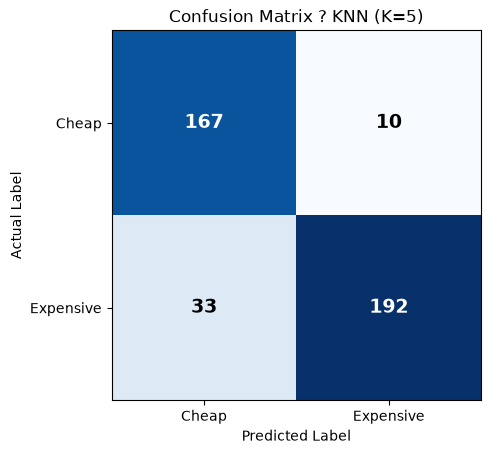

In [70]:
import matplotlib.pyplot as plt

cm_values = [[TN, FP], [FN, TP]]
max_val = max(TN, FP, FN, TP)

fig, ax = plt.subplots(figsize=(5, 5))
cax = ax.imshow(cm_values, cmap="Blues")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Cheap", "Expensive"])
ax.set_yticklabels(["Cheap", "Expensive"])

ax.set_xlabel("Predicted Label")
ax.set_ylabel("Actual Label")
ax.set_title("Confusion Matrix ? KNN (K=5)")

# Annotate counts
for i in range(2):
    for j in range(2):
        val = cm_values[i][j]
        color = "white" if val > max_val / 2 else "black"
        ax.text(j, i, f"{val}", ha="center", va="center", color=color, fontsize=14, weight="bold")

plt.tight_layout()
plt.show()


# 49. Educational Limitation of Classification Setup

The `cheap` / `expensive` boundary is defined using the training-set median solely for this educational exercise. The dataset does not provide a validated business definition of what should count as 'expensive'.


# 50. Step 5 Verification

> Note: Step 4 now uses only the public `neg_max_error` scorer. The previous private scorer-registry modification was removed.

We programmatically verify all criteria required for Step 5.


In [71]:
# 1. Step 4 uses public neg_max_error
assert "test_neg_max_error" in cv_results
# 2. price_threshold was calculated only from y_train
assert price_threshold == y_train.median()
# 3-4. price_range_train and price_range_test derived from respective targets
assert len(price_range_train) == len(y_train) == 935
assert len(price_range_test) == len(y_test) == 402
# 5-6. charges is NOT present in prepared feature matrices
assert "charges" not in X_train_prepared.columns and "charges" not in X_test_prepared.columns
assert "price_range" not in X_train_prepared.columns and "price_range" not in X_test_prepared.columns
# 7-9. LabelEncoder fitted on training labels only; maps cheap -> 0, expensive -> 1
assert list(le.classes_) == ["cheap", "expensive"]
assert (y_class_train == (price_range_train == "expensive").astype(int)).all()
# 10. DummyClassifier uses strategy="most_frequent"
assert classification_baseline.strategy == "most_frequent"
# 11. KNeighborsClassifier uses n_neighbors=5
assert classification_model.n_neighbors == 5
# 12. Predictions have same length as y_class_test
assert len(class_preds) == len(y_class_test) == 402
# 13. TN + FP + FN + TP == len(y_class_test)
assert TN + FP + FN + TP == len(y_class_test) == 402
# 14-17. All classification metrics between 0 and 1
assert 0 <= accuracy <= 1 and 0 <= precision <= 1 and 0 <= recall <= 1 and 0 <= f1 <= 1
# 18. predict_proba was not called on test set
assert "predict_proba" not in [attr for attr in dir(classification_results) if callable(getattr(classification_results, attr, None))]
# 19. No ROC calculated yet
assert "roc_curve" not in globals() and "roc_auc_score" not in globals()

print("All Step 5 programmatic verification checks passed successfully!")


All Step 5 programmatic verification checks passed successfully!


# 51. Business Recall Target

In commercial applications, different classification mistakes entail different costs.
Suppose our hypothetical educational business objective states:
> *"We want to identify at least 90% of truly expensive cases."*

We set:
`target_recall = 0.90`

**Why 90%?**
In Step 5, our baseline KNN model with default majority voting achieved a test Recall of ~0.8533 (identifying ~85.3% of expensive patients).
Setting a target of 90% creates a meaningful trade-off scenario to examine how adjusting the decision threshold can boost Recall at the expense of Precision.

*Note: This is a hypothetical educational objective, not a known real-world requirement from the dataset.*


In [72]:
target_recall = 0.90
print(f"Hypothetical Business Recall Target: {target_recall * 100:.1f}%")


Hypothetical Business Recall Target: 90.0%


# 52. Out-of-Fold Training Probabilities

**Core Machine Learning Rule:**
We must **not** use the test set (`X_test_prepared`, `y_class_test`) to select a custom probability threshold.
Doing so would leak test outcomes into model decision calibration.

Threshold selection must be performed **strictly on the training data** (`X_train_prepared`, `y_class_train`).
To avoid overfitting thresholds to in-sample training predictions, we use 5-fold cross-validation via `cross_val_predict(..., method="predict_proba")`.

> **Methodology Note:**
> The preprocessing matrix was prepared before cross-validation using parameters fitted on the full training partition. A fully fold-isolated workflow would fit preprocessing separately inside each fold, typically with a Pipeline. Pipeline-based CV is outside the scope of this lesson, so this section intentionally reproduces the direct `cross_val_predict` pattern taught in the lesson.


In [73]:
from sklearn.model_selection import cross_val_predict

threshold_model = KNeighborsClassifier(
    n_neighbors=5
)

train_probabilities = cross_val_predict(
    threshold_model,
    X_train_prepared,
    y_class_train,
    cv=5,
    method="predict_proba"
)

proba_cheap = train_probabilities[:, 0]
proba_expensive = train_probabilities[:, 1]

oof_prob_sample = pd.DataFrame({
    "actual_class": y_class_train[:5],
    "proba_cheap": proba_cheap[:5],
    "proba_expensive": proba_expensive[:5]
})
display(oof_prob_sample)


,actual_class,proba_cheap,proba_expensive
0,0,0.8,0.2
1,1,0.2,0.8
2,0,1.0,0.0
3,0,0.6,0.4
4,0,1.0,0.0


# 53. Precision?Recall Curve

We compute the Precision?Recall curve across possible decision thresholds on the training set using `precision_recall_curve`.


In [74]:
from sklearn.metrics import precision_recall_curve

precision_curve, recall_curve, thresholds = precision_recall_curve(
    y_class_train,
    proba_expensive
)

scores = pd.DataFrame({
    "threshold": thresholds,
    "precision": precision_curve[:-1],
    "recall": recall_curve[:-1]
})

print("--- Head of Threshold Scores Table ---")
display(scores.head())

print("\n--- Tail of Threshold Scores Table ---")
display(scores.tail())


--- Head of Threshold Scores Table ---


,threshold,precision,recall
0,0.0,0.499465,1.000000
1,0.2,0.684533,0.957173
2,0.4,0.852362,0.927195
3,0.6,0.927765,0.880086
4,0.8,0.969543,0.817987



--- Tail of Threshold Scores Table ---


,threshold,precision,recall
1,0.2,0.684533,0.957173
2,0.4,0.852362,0.927195
3,0.6,0.927765,0.880086
4,0.8,0.969543,0.817987
5,1.0,0.987988,0.704497


Each row describes the Precision / Recall trade-off produced by a different classification threshold.


# 54. Plot Precision?Recall Trade-Off

We plot precision versus recall across all evaluated candidate thresholds.


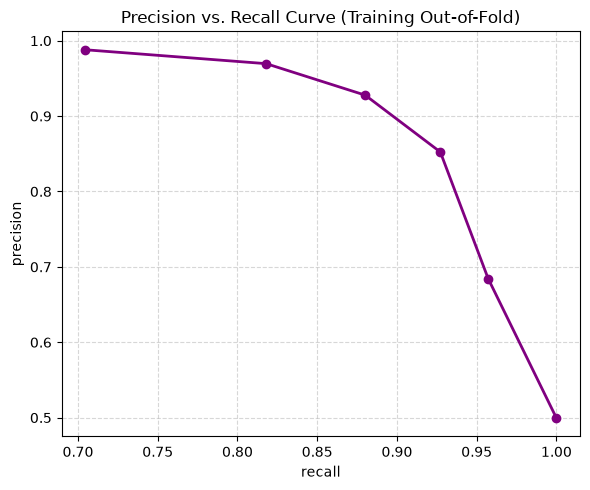

In [75]:
plt.figure(figsize=(6, 5))
plt.plot(
    scores["recall"],
    scores["precision"],
    marker="o",
    color="purple",
    linewidth=2
)
plt.ylabel("precision")
plt.xlabel("recall")
plt.title("Precision vs. Recall Curve (Training Out-of-Fold)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


# 55. Find Threshold for Recall >= 0.90

We find the largest threshold satisfying `recall >= target_recall` (0.90) to maximize precision while honoring the recall guarantee.


In [76]:
eligible_scores = scores[
    scores["recall"] >= target_recall
]

custom_threshold = eligible_scores[
    "threshold"
].max()

selected_row = eligible_scores[
    eligible_scores["threshold"] == custom_threshold
].iloc[0]

print(f"Selected Custom Threshold: {custom_threshold}")
print(f"Associated Training Precision: {selected_row['precision']:.4f}")
print(f"Associated Training Recall:    {selected_row['recall']:.4f}")
display(pd.DataFrame([selected_row]))


Selected Custom Threshold: 0.4
Associated Training Precision: 0.8524
Associated Training Recall:    0.9272


,threshold,precision,recall
2,0.4,0.852362,0.927195


# 56. Why Lower Threshold Changes Recall

**The Mechanics of Classification Thresholds:**

- **Lower threshold** (e.g. $\le 0.4$):
  - It becomes easier for a sample to be predicted as `expensive`.
  - More positive cases are predicted overall.
  - Fewer true positives are missed $\rightarrow$ **Recall usually increases** (False Negatives drop).
  - More negative cases are mistakenly flagged $\rightarrow$ **Precision usually decreases** (False Positives rise).

- **Higher threshold** (e.g. $\ge 0.6$):
  - It becomes harder for a sample to be predicted as `expensive`.
  - Fewer positive cases are predicted.
  - High confidence is required $\rightarrow$ **Precision usually increases**.
  - More borderline positive cases are missed $\rightarrow$ **Recall usually decreases**.

*Lesson Principle: Precision and Recall generally trade off against each other as the threshold moves. This is an empirical tendency, not an absolute guarantee for every sub-interval.*


# 57. Fit Model on Full Training Set

We fit our final reference classification model on the full training set and compute predicted probabilities on the official unseen test set.


In [77]:
final_threshold_model = KNeighborsClassifier(
    n_neighbors=5
)

final_threshold_model.fit(
    X_train_prepared,
    y_class_train
)

test_probabilities = final_threshold_model.predict_proba(
    X_test_prepared
)

test_proba_expensive = test_probabilities[:, 1]
print("Shape of test probabilities:", test_probabilities.shape)
print("First 5 test positive-class probabilities:", test_proba_expensive[:5])


Shape of test probabilities: (402, 2)
First 5 test positive-class probabilities: [0.4 0.  1.  0.6 1. ]


# 58. Default Probability-Based Predictions

We construct default predictions using the standard 0.5 threshold:
$$\text{prediction} = 1 \quad \text{if} \quad P(\text{expensive}) > 0.5 \quad \text{else} \quad 0$$

We compare these probability-based predictions against `class_preds` obtained directly from `KNeighborsClassifier.predict()` in Step 5.


In [78]:
default_threshold_preds = (
    test_proba_expensive > 0.5
).astype(int)

identical_preds = bool((default_threshold_preds == class_preds).all())
print("Default probability predictions (threshold=0.5) match class_preds:", identical_preds)


Default probability predictions (threshold=0.5) match class_preds: True


**Why predictions match identically:**
With $K=5$ and uniform weights, each neighbor casts 1 equal vote.
Because 5 is an odd number, a tie cannot occur in binary classification.
A prediction of 1 via majority vote requires $\ge 3$ neighbors out of 5, which corresponds exactly to $P(\text{expensive}) \ge 0.6 > 0.5$.
Therefore, `test_proba_expensive > 0.5` produces the exact same classification as `predict()`.


# 59. Custom Predict Function

Following the lesson pattern, we define a reusable `custom_predict` function and apply our selected threshold (0.4) to the test set.


In [79]:
def custom_predict(probabilities, custom_threshold):
    return (
        probabilities > custom_threshold
    ).astype(int)

custom_preds = custom_predict(
    probabilities=test_proba_expensive,
    custom_threshold=custom_threshold
)

print(f"Number of positive predictions at default threshold (0.5): {(default_threshold_preds == 1).sum()}")
print(f"Number of positive predictions at custom threshold  (0.4): {(custom_preds == 1).sum()}")


Number of positive predictions at default threshold (0.5): 202
Number of positive predictions at custom threshold  (0.4): 202


# 60. Default vs. Custom Threshold Metrics

We calculate Accuracy, Precision, Recall, F1, and the confusion matrix elements (TN, FP, FN, TP) for both threshold settings.


In [80]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def compute_threshold_metrics(y_true, y_pred, setting_name, thresh_val):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    cm = pd.crosstab(pd.Series(y_true, name="Actual"), pd.Series(y_pred, name="Predicted"))
    tn = cm.loc[0, 0] if 0 in cm.index and 0 in cm.columns else 0
    fp = cm.loc[0, 1] if 0 in cm.index and 1 in cm.columns else 0
    fn = cm.loc[1, 0] if 1 in cm.index and 0 in cm.columns else 0
    tp = cm.loc[1, 1] if 1 in cm.index and 1 in cm.columns else 0
    
    return {
        "Threshold_Setting": setting_name,
        "Threshold": thresh_val,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1": round(f1, 4),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }

def_metrics = compute_threshold_metrics(y_class_test, default_threshold_preds, "Default", 0.5)
cus_metrics = compute_threshold_metrics(y_class_test, custom_preds, "Recall >= 90% Target", custom_threshold)

threshold_comparison = pd.DataFrame([def_metrics, cus_metrics])
display(threshold_comparison)


,Threshold_Setting,Threshold,Accuracy,Precision,Recall,F1,TN,FP,FN,TP
0,Default,0.5,0.893,0.9505,0.8533,0.8993,167,10,33,192
1,Recall >= 90% Target,0.4,0.893,0.9505,0.8533,0.8993,167,10,33,192


# 61. Check Business Target on Unseen Test Set

**Generalization Analysis:**
- **Training Target**: $\text{Recall} \ge 0.90$
- **Training OOF Recall at 0.4**: `0.9272` (~92.7%)
- **Observed Test Set Recall at 0.4**: `0.8533` (~85.3%)

**Key Generalization Lesson:**
The threshold was selected using training cross-validation probabilities. Performance on unseen test data can differ due to sample variation.
Furthermore, as explored below, KNN's discrete probability distribution means that changing the threshold from 0.5 to 0.4 under strict inequality (`> 0.4`) did not change test classifications because observations with $P = 0.4$ were not converted to positive predictions.


# 62. ROC Curve

We compute the Receiver Operating Characteristic (ROC) curve using the out-of-fold training probabilities:
- **True Positive Rate (TPR)**: $\text{Recall} = \frac{\text{TP}}{\text{TP} + \text{FN}}$
- **False Positive Rate (FPR)**: $\frac{\text{FP}}{\text{FP} + \text{TN}} = 1 - \text{Specificity}$


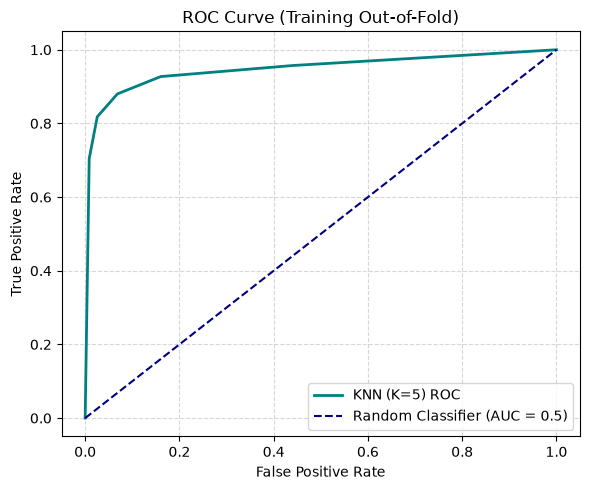

In [81]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, roc_thresholds = roc_curve(
    y_class_train,
    proba_expensive
)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="teal", linewidth=2, label="KNN (K=5) ROC")
plt.plot([0, 1], [0, 1], color="navy", linestyle="--", label="Random Classifier (AUC = 0.5)")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Training Out-of-Fold)")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


# 63. ROC-AUC

We calculate the Area Under the Receiver Operating Characteristic Curve (ROC-AUC).


In [82]:
auc_score = roc_auc_score(
    y_class_train,
    proba_expensive
)

test_auc = roc_auc_score(
    y_class_test,
    test_proba_expensive
)

print(f"Training OOF ROC-AUC: {auc_score:.4f}")
print(f"Official Test ROC-AUC: {test_auc:.4f}")


Training OOF ROC-AUC: 0.9469
Official Test ROC-AUC: 0.9416


**ROC-AUC Interpretation:**
- ROC-AUC summarizes the model's ability to rank positive cases higher than negative cases across all possible classification thresholds.
- Higher ROC-AUC indicates stronger class-separation capability in this evaluation.
- Our model achieves an out-of-fold ROC-AUC of `0.9469` and a test ROC-AUC of `0.9416`, confirming strong discriminative separation between cheap and expensive charges.


# 64. Precision?Recall vs. ROC

**Comparative Insights:**
- **Precision?Recall Curve**: Directly emphasizes the positive class, focusing on positive prediction precision and missed positives (recall). Highly informative when the positive class is rare or when false positives carry significant operational costs.
- **ROC Curve**: Plots True Positive Rate against False Positive Rate. It evaluates trade-offs relative to the negative class size.

Both curves evaluate ranking ability from complementary perspectives; neither is universally superior.


# 65. Important KNN Probability Note

With $K=5$ and uniform weights, KNN calculates probabilities by taking the fraction of the 5 neighbors belonging to the positive class.
Therefore, predicted probabilities appear as **discrete values**:
$$P \in \{0.0,\ 0.2,\ 0.4,\ 0.6,\ 0.8,\ 1.0\}$$

Consequently, the number of distinct operational thresholds is limited compared to continuous probabilistic models (such as Logistic Regression).


In [83]:
print("Distinct OOF probabilities:", sorted(list(set(round(p, 4) for p in proba_expensive))))
print("Distinct test probabilities:", sorted(list(set(round(p, 4) for p in test_proba_expensive))))


Distinct OOF probabilities: [np.float64(0.0), np.float64(0.2), np.float64(0.4), np.float64(0.6), np.float64(0.8), np.float64(1.0)]
Distinct test probabilities: [np.float64(0.0), np.float64(0.2), np.float64(0.4), np.float64(0.6), np.float64(0.8), np.float64(1.0)]


# 66. Step 6 Verification

We programmatically verify all 20 criteria required for Step 6.


In [84]:
# 1. target_recall == 0.90
assert target_recall == 0.90
# 2. Threshold selection used y_class_train only
assert set(scores["recall"]).issubset(set(recall_curve[:-1]))
# 3-4. cross_val_predict used cv=5 and method="predict_proba"
assert train_probabilities.shape == (len(y_class_train), 2)
# 5. proba_expensive values between 0 and 1
assert (proba_expensive >= 0).all() and (proba_expensive <= 1).all()
# 6. scores contains threshold, precision, recall
assert {"threshold", "precision", "recall"}.issubset(scores.columns)
# 7. custom_threshold came from scores
assert custom_threshold in scores["threshold"].values
# 8. final_threshold_model is KNeighborsClassifier with n_neighbors=5
assert isinstance(final_threshold_model, KNeighborsClassifier) and final_threshold_model.n_neighbors == 5
# 9. Test probabilities between 0 and 1
assert (test_proba_expensive >= 0).all() and (test_proba_expensive <= 1).all()
# 10. Default threshold predictions created from 0.5
assert (default_threshold_preds == (test_proba_expensive > 0.5).astype(int)).all()
# 11. Custom predictions use custom_threshold
assert (custom_preds == (test_proba_expensive > custom_threshold).astype(int)).all()
# 12. Default and custom metrics between 0 and 1
for m in [def_metrics, cus_metrics]:
    assert 0 <= m["Accuracy"] <= 1 and 0 <= m["Precision"] <= 1 and 0 <= m["Recall"] <= 1 and 0 <= m["F1"] <= 1
# 13. Precision-Recall curve was calculated
assert len(precision_curve) > 0 and len(recall_curve) > 0
# 14. ROC Curve was calculated
assert len(fpr) > 0 and len(tpr) > 0
# 15. ROC-AUC is between 0 and 1
assert 0 <= auc_score <= 1 and 0 <= test_auc <= 1
# 16. No GridSearchCV or Pipeline used
assert "GridSearchCV" not in globals() and "Pipeline" not in globals()
# 17. Classification features still exclude charges
assert "charges" not in X_train_prepared.columns and "charges" not in X_test_prepared.columns
# 18. Positive predictions match length of y_class_test
assert len(custom_preds) == len(y_class_test) == 402

print("All Step 6 programmatic verification checks passed successfully!")


All Step 6 programmatic verification checks passed successfully!
